In [15]:
import os, sys, pathlib, importlib
import pandas as pd
import json
import time
from tqdm import tqdm
sys.path.append(os.path.abspath(".."))
from utils import download_pic
from utils.download_pic import download_images_batch

## check

43056 23789
18682


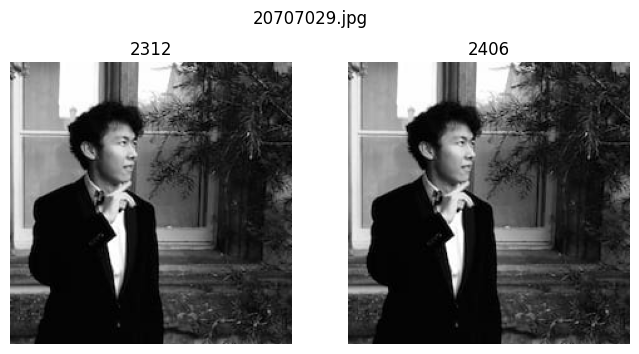

In [ ]:
## check duplicates:
import matplotlib.pyplot as plt

folder1='images\paris_2406'
folder2='images\paris_2312'
paris2312=os.listdir(folder1)
paris2406=os.listdir(folder2)

print(len(paris2312), len(paris2406))
comm=list(set(paris2312).intersection(set(paris2406)))
print(len(comm))


## vis
import matplotlib.pyplot as plt
import os


f=comm[10]
img1 = plt.imread(os.path.join(folder1, f))
img2 = plt.imread(os.path.join(folder2, f))

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img1)
plt.title('2312')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img2)
plt.title('2406')
plt.axis('off')

plt.suptitle(f)
plt.show()


## input 22032026


In [14]:
DATA_FOLDER="../data_processed"
IMAGES_FOLDER='images'

os.makedirs(IMAGES_FOLDER, exist_ok=True)

input_output={}
for folder in [ f for f in os.listdir(DATA_FOLDER) if not f.endswith('.csv')]:
    # folder = city+time

    # ---listings---
    files=os.listdir(os.path.join(DATA_FOLDER, folder))
    for f in files:
        if f.startswith('listings_processed'):
            path_listings=os.path.join(DATA_FOLDER, folder, f)
            path_listings_zsc=os.path.join(DATA_FOLDER, folder, f"listings_zsc_{folder}.csv")
    path_results_zsc=os.path.join(DATA_FOLDER, folder, f"resultsZSC_{folder}.csv")

    # ---images folder---
    pic_folder=os.path.join(IMAGES_FOLDER, folder)
    os.makedirs(pic_folder, exist_ok=True)

    # --resultsface---
    resultsFACE_folder=os.path.join(IMAGES_FOLDER, 'results')
    os.makedirs(resultsFACE_folder, exist_ok=True)

    path_results_face=os.path.join(resultsFACE_folder, f"face_{folder}.json")
    path_results_deepface=os.path.join(resultsFACE_folder, f"deepface_{folder}.json")

    # ---gather---
    input_output[folder]={"listings":path_listings,
              "results_zsc":path_results_zsc,
              "listings_zsc":path_listings_zsc,

              'pic_folder':pic_folder,
              'results_face':path_results_face,
              "results_deepface":path_results_deepface}

for k,v in input_output.items():
    print(f"{k}".center(100,'-'))
    path_listings=v['listings']
    path_results_zsc=v['results_zsc']
    path_listings_zsc=v['listings_zsc']

    pic_folder=v['pic_folder']
    path_results_face=v['results_face']
    path_results_deepface=v['results_deepface']
    print('DATA:')
    print(path_listings)
    print(path_results_zsc)
    print(path_listings_zsc,"\n")
    print("PIC FOLDER: ",pic_folder)
    print(path_results_face)
    print(path_results_deepface,"\n")

--------------------------------------------london_2306---------------------------------------------
DATA:
../data_processed\london_2306\listings_processed_london_2306_42356.csv
../data_processed\london_2306\resultsZSC_london_2306.csv
../data_processed\london_2306\listings_zsc_london_2306.csv 

PIC FOLDER:  images\london_2306
images\results\face_london_2306.json
images\results\deepface_london_2306.json 

--------------------------------------------london_2406---------------------------------------------
DATA:
../data_processed\london_2406\listings_processed_london_2406_49856.csv
../data_processed\london_2406\resultsZSC_london_2406.csv
../data_processed\london_2406\listings_zsc_london_2406.csv 

PIC FOLDER:  images\london_2406
images\results\face_london_2406.json
images\results\deepface_london_2406.json 

---------------------------------------------paris_2306---------------------------------------------
DATA:
../data_processed\paris_2306\listings_processed_paris_2306_32901.csv
../data_

## download pics

In [20]:
importlib.reload(download_pic)
from utils.download_pic import download_images_batch

path_df=input_output['paris_2406']['listings']
pic_folder=input_output['paris_2406']['pic_folder']
df=download_images_batch(path_df=path_df, pic_folder=pic_folder, max_workers=10)

[check]host_pic_is_valid
True     43071
False      186
Name: count, dtype: int64
[info] filtered by 'host_pic_is_valid'!
[check] has pic+ dropna + drop_duplicates: 62738 => 0!
[info] ALL pics downloaded:)



In [25]:
importlib.reload(download_pic)
from utils.download_pic import download_images_batch

for i, paths in input_output.items():
    print(f"{i}".center(100,'-'))    
    path_df=paths['listings']
    pic_folder=paths['pic_folder']
    print(f"path df:{path_df}")
    print(f"pic_folder: {pic_folder}")
    df=download_images_batch(path_df=path_df, pic_folder=pic_folder, max_workers=10)
    # break
# 20K 90mins

--------------------------------------------london_2306---------------------------------------------
path df:../data_processed\london_2306\listings_processed_london_2306_42356.csv
pic_folder: images\london_2306
[check]host_pic_is_valid
True     22002
False      249
Name: count, dtype: int64
[info] filtered by 'host_pic_is_valid'!
[check] has pic+ dropna + drop_duplicates: 42356 => 0!
[info] ALL pics downloaded:)

--------------------------------------------london_2406---------------------------------------------
path df:../data_processed\london_2406\listings_processed_london_2406_49856.csv
pic_folder: images\london_2406
[check] has pic+ dropna + drop_duplicates: 49856 => 25079!
[info] 24819/25079 downloaded; 260 /25079 to download!

[info] no / no valid host pic: 2403/25079.




[warning] invalid URL: https://a0.muscache.com/im/pictures/user/032b1ffd-624b-4803-b214-46d93e66f5fa.jpg?aki_policy=profile_x_medium

[warning] invalid URL: https://a0.muscache.com/im/pictures/user/User-558720586/original/6055dfd9-0d3c-4767-845d-0139ae1158e2.jpeg?aki_policy=profile_x_medium

[warning] invalid URL: https://a0.muscache.com/im/pictures/user/491ae4d0-1670-4426-8cc5-b03392eead99.jpg?aki_policy=profile_x_medium

[warning] invalid URL: https://a0.muscache.com/im/users/13278656/profile_pic/1395186363/original.jpg?aki_policy=profile_x_medium

[warning] invalid URL: https://a0.muscache.com/im/pictures/user/8f61fc21-c941-46b2-a1b0-50d3641e9f48.jpg?aki_policy=profile_x_medium

[warning] invalid URL: https://a0.muscache.com/im/pictures/user/9868ef0e-4794-410b-bd23-cb04b908ed4a.jpg?aki_policy=profile_x_medium

[warning] invalid URL: https://a0.muscache.com/im/pictures/user/a53dbc41-91f2-4353-9421-75640dbf0f9a.jpg?aki_policy=profile_x_medium



[warning] invalid URL: https://a0.muscache.com/im/pictures/user/c3788d39-0fbf-4659-a21f-fb57c55aaf8d.jpg?aki_policy=profile_x_medium



[warning] invalid URL: https://a0.muscache.com/im/pictures/user/c3732e06-6ade-4697-a5a8-5982d3072c16.jpg?aki_policy=profile_x_medium



[warning] invalid URL: https://a0.muscache.com/im/pictures/user/User-571222269/original/8afc60c5-9bc3-4c9a-aae6-eb37131b7c80.jpeg?aki_policy=profile_x_medium

[warning] invalid URL: https://a0.muscache.com/im/pictures/user/cdb55b64-42e3-4a2b-b343-2ea627623423.jpg?aki_policy=profile_x_medium

[warning] invalid URL: https://a0.muscache.com/im/pictures/user/386be4e9-2810-452f-bb43-b09227103e6d.jpg?aki_policy=profile_x_medium

[warning] invalid URL: https://a0.muscache.com/im/pictures/user/User-497291400/original/04d78d03-a6bf-43c4-a37d-d2b08cb6bc19.jpeg?aki_policy=profile_x_medium

[warning] invalid URL: https://a0.muscache.com/im/pictures/user/caa53b56-ffe7-44cc-9e28-0c7ef755d601.jpg?aki_policy=profile_x_medium


...


[warning] invalid URL: https://a0.muscache.com/im/pictures/803c723c-8cdc-4d83-81c1-001fe0c5bee1.jpg?aki_policy=profile_x_medium



[warning] invalid URL: https://a0.muscache.com/im/pictures/user/User-517495309/original/6e10e206-5cf1-4431-ac74-71639a13a78b.jpeg?aki_policy=profile_x_medium



[warning] invalid URL: https://a0.muscache.com/im/pictures/user/eef90319-e66b-43d5-9c0b-1bd7f665a3c4.jpg?aki_policy=profile_x_medium



[warning] invalid URL: https://a0.muscache.com/im/pictures/user/25610807-3c04-4100-ac39-9901348d0ec5.jpg?aki_policy=profile_x_medium



[DONE] 21804 pics downloaded : 4939.06 sec!

[update] host_pic_is_valid
True     31988
False      913
Name: count, dtype: int64
[save] df with 'host_pic_is_valid' updated saved to ../data_processed\paris_2306\listings_processed_paris_2306_32901.csv.

---------------------------------------------paris_2406---------------------------------------------
path df:../data_processed\paris_2406\listings_processed_paris_2406_62738.csv
pic_folder: images\paris_2406
[check]host_pic_is_valid
True     43071
False      186
Name: count, dtype: int64
[info] filtered by 'host_pic_is_valid'!
[check] has pic+ dropna + drop_duplicates: 62738 => 0!
[info] ALL pics downloaded:)



In [ ]:
# paris 2306 [DONE] 21804 pics downloaded : 4939.06 sec!